In [1]:
import numpy as np

from matplotlib import pyplot as plt
from scipy.stats import norm

from npkwt import NPKWTNormal, NPKWTNormalLimited

In [2]:
# Approximate test on log_z grid with step size 0.05
log_z_grid = np.linspace(-40, 41, 1601)

### Limited Randomness Case

In [3]:
# Use at most 10 randomized stopping rules
k = 10
# Use 10 points per unit interval for c grid (dc = 0.1)
c_ppui = 10

In [4]:
# Initialize and solve NPKWT, use base 2 for log-likelihood ratio
npkwt_normal_limited = NPKWTNormalLimited(k, 1)
npkwt_normal_limited.setup(log_z_grid, c_ppui)

Solving k = 1
Solving k = 2
Solving k = 3
Solving k = 4
Solving k = 5
Solving k = 6
Solving k = 7
Solving k = 8
Solving k = 9
Solving k = 10


### Unlimited Randomness Case

In [5]:
# Initialize and solve NPKWT, use base 2 for log-likelihood ratio
npkwt_normal = NPKWTNormal(1)
npkwt_normal.setup(log_z_grid)

Iteration 1: diff = 0.4072146160725155
Iteration 2: diff = 0.0297557545933812
Iteration 3: diff = 0.00886176391496335
Iteration 4: diff = 0.0039126975684583565
Iteration 5: diff = 0.002020354963852722
Iteration 6: diff = 0.0011687819831472934
Iteration 7: diff = 0.0007300331781780467
Iteration 8: diff = 0.0004795647095275357
Iteration 9: diff = 0.00032527611487598307
Iteration 10: diff = 0.00023020456458788807
Iteration 11: diff = 0.00016937552721363325
Iteration 12: diff = 0.00012522246140489468
Iteration 13: diff = 9.519544812189307e-05
Iteration 14: diff = 7.302798245542585e-05
Iteration 15: diff = 5.6321764953126685e-05
Iteration 16: diff = 4.402724757468501e-05
Iteration 17: diff = 3.50122974002165e-05
Iteration 18: diff = 2.7825613297699503e-05
Iteration 19: diff = 2.223205776560877e-05
Iteration 20: diff = 1.770303110767979e-05
Iteration 21: diff = 1.4052572142375652e-05
Iteration 22: diff = 1.1139282461214428e-05
Iteration 23: diff = 8.8051787084098e-06
Iteration 24: diff = 6.9

### Figure 1

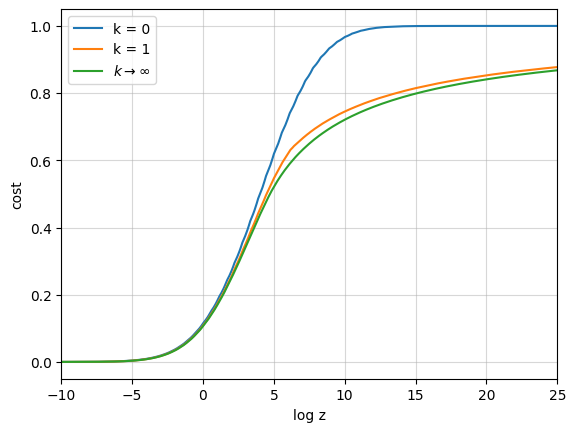

In [6]:
plt.plot(log_z_grid, npkwt_normal_limited.rho(0, log_z_grid, 10), label="k = 0")
plt.plot(log_z_grid, npkwt_normal_limited.rho(1, log_z_grid, 10), label="k = 1")
plt.plot(log_z_grid, npkwt_normal.rho(log_z_grid, 10), label=r"$k \to \infty$")
plt.xlim(-10, 25)
plt.xlabel("log z")
plt.ylabel("cost")
plt.legend()
plt.grid(alpha=0.5)

### Figure 2

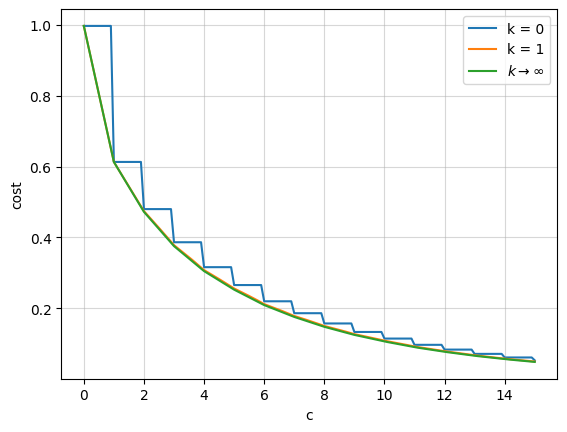

In [7]:
c_grid = np.linspace(0, 15, 151)
plt.plot(c_grid, npkwt_normal_limited.rho(0, 0, c_grid), label="k = 0")
plt.plot(c_grid, npkwt_normal_limited.rho(1, 0, c_grid), label="k = 1")
plt.plot(c_grid, npkwt_normal.rho(0, c_grid), label=r"$k \to \infty$")
plt.xlabel("c")
plt.ylabel("cost")
plt.legend()
plt.grid(alpha=0.5)

### Figure 3

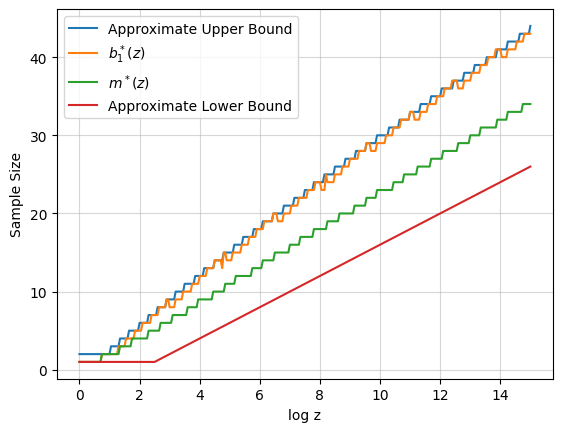

In [8]:
log_z_pos = np.linspace(0, 15, 301)
plt.plot(log_z_pos, [npkwt_normal.m_star_ub(log_z) for log_z in log_z_pos], label="Approximate Upper Bound")
plt.plot(log_z_pos, [npkwt_normal_limited.b_star(0, log_z) for log_z in log_z_pos], label=r"$b_1^*(z)$")
plt.plot(log_z_pos, [npkwt_normal.m_star(log_z) for log_z in log_z_pos], label=r"$m^*(z)$")
plt.plot(log_z_pos, [npkwt_normal.m_star_lb(log_z) for log_z in log_z_pos], label="Approximate Lower Bound")
plt.xlabel("log z")
plt.ylabel("Sample Size")
plt.legend()
plt.grid(alpha=0.5)

### Figure 4

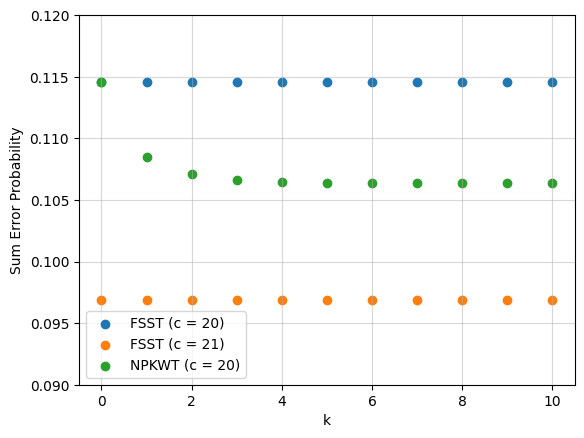

In [9]:
plt.scatter(np.arange(11), [npkwt_normal_limited.rho(0, 0, 10) for _ in range(11)], label="FSST (c = 20)")
plt.scatter(np.arange(11), [npkwt_normal_limited.rho(0, 0, 11) for _ in range(11)], label="FSST (c = 21)")
plt.scatter(np.arange(11), [npkwt_normal_limited.rho(k, 0, 10) for k in range(11)], label="NPKWT (c = 20)")
plt.xlabel("k")
plt.ylabel("Sum Error Probability")
plt.ylim(0.09, 0.12)
plt.legend()
plt.grid(alpha=0.5)

### Figure 5

In [ ]:
# Simulate 10,000 runs (this will take some time, consider reducing the number for a quick glance...)
D, T, N_rand = npkwt_normal.simulate(0, 10, norm, 10000)

 68%|████████████████████████████████████████████████████████████████▊                              | 6824/10000 [01:10<00:33, 95.29it/s]

In [ ]:
plt.hist(T, bins=np.arange(51), density=True);

### Figure 6

In [ ]:
plt.hist(N_rand, bins=np.arange(31), density=True);